In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# XOR Expirement with linear and non-linear models

In [61]:
# The XOR Data
X = torch.tensor([[0,0], [0,1], [1,0], [1,1]], dtype=torch.float32)
Y = torch.tensor([[0], [1], [1], [0]], dtype=torch.float32)

# Model 1: Linear (No activation function)
model_linear = nn.Sequential(
    nn.Linear(2, 4, bias=False), # Hidden layer
    nn.Linear(4, 1, bias=False)  # Output layer
)

# Model 2: Non-Linear (With ReLU)
model_nonlinear = nn.Sequential(
    nn.Linear(2, 4, bias=False), # Hidden layer
    nn.GELU(),       # The Non-Linearity
    nn.Linear(4, 1, bias=False)  # Output layer
)

def train(model, name):
    optimizer = optim.SGD(model.parameters(), lr=0.1)
    criterion = nn.MSELoss()
    for epoch in range(1000):
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        optimizer.step()
    
    print(f"\n--- Results for {name} ---")
    print(f"Final Loss: {loss.item():.4f}")
    print("Predictions:")
    print(model(X).detach().numpy().round(2))

train(model_linear, "Linear Model")
train(model_nonlinear, "Non-Linear Model (ReLU)")


--- Results for Linear Model ---
Final Loss: 0.3333
Predictions:
[[0.  ]
 [0.33]
 [0.33]
 [0.67]]

--- Results for Non-Linear Model (ReLU) ---
Final Loss: 0.0000
Predictions:
[[0.]
 [1.]
 [1.]
 [0.]]


In [ ]:
# predictions
print(model_nonlinear[0].weight.shape)
out = X @ model_nonlinear[0].weight.T
out = model_nonlinear[1](out)
out = out @ model_nonlinear[2].weight.T
print(out)

torch.Size([4, 2])
tensor([[0.0000e+00],
        [1.0000e+00],
        [1.0000e+00],
        [1.1623e-06]], grad_fn=<MmBackward0>)


# Logistic Regression examples of data, clustered

(400, 2)
(400,)


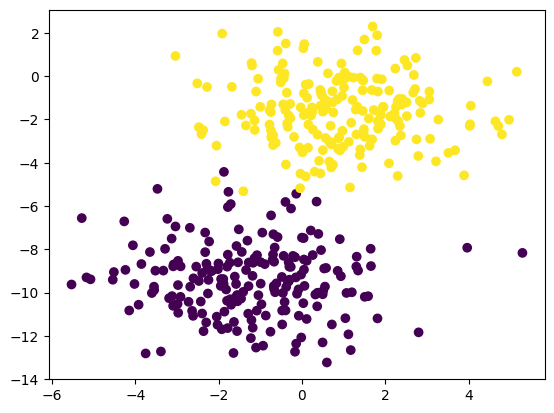

In [160]:
from sklearn.datasets  import make_blobs

I,t = make_blobs(n_samples = [200, 200], random_state=2, cluster_std=1.6)
# random_state=2

print(I.shape)
print(t.shape)

plt.scatter(I[:,0], I[:,1], c=t)
plt.show()

[0 0 1 1]


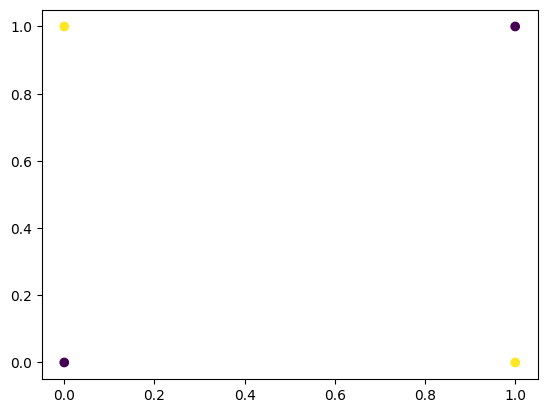

In [191]:
X = np.array([[0,0], [0, 1], [1,0], [1,1]])
orr = [0, 1, 1, 0]
co = orr*2
print(X[:, 0])

plt.scatter(X[:, 0], X[:, 1], c=orr)

# Linear vs Non-Linear models for non linear equaltions like parabola

In [222]:
# We will examine to train a non linear equation "y = x^2 - 3x -9" parabolic eq.
# See how a linear model vs non linear model works

torch.Size([400])
torch.Size([400])
Reshaped XH torch.Size([400, 1])
Reshaped y torch.Size([400, 1])


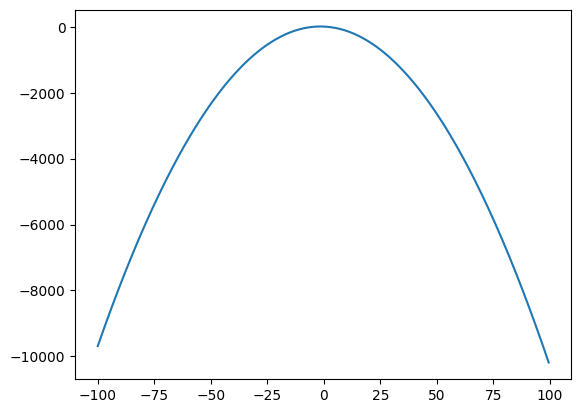

In [155]:
XH = torch.arange(-100, 100, 0.5)

y = 20 - XH**2 - 3*XH - 9
# y = torch.where(y >= 0, y**0.5, torch.tensor(float('nan')))
# XH = torch.cat([XH, XH])
# y = torch.cat([y, -y])
# print(XH)
# print(y)
print(XH.shape)
print(y.shape)

plt.plot(XH, y)

XH = XH.view(-1, 1)
y = y.view(-1, 1)

print("Reshaped XH", XH.shape)
print("Reshaped y", y.shape)


In [156]:
def trainModel(model, x, y, n=100, lr=0.01, clip_grad=True, max_norm=1.0, verbose=False):
    loss_per_epoch = torch.zeros(n)
    for i in range(n):
        Xhat = model(x)
        loss = torch.nn.functional.mse_loss(Xhat, y)

        # Check for NaN
        if torch.isnan(loss):
            print(f"NaN detected at epoch {i}")
            break

        loss_per_epoch[i] = loss.item()
        
        for p in model.parameters():
            p.grad = None
        loss.backward()

        # MANUAL Gradient clipping
        if clip_grad:
            # Step 1: Calculate total gradient norm (L2 norm) across ALL parameters
            # norm = sqrt(grad1² + grad2² + ... + gradN²)
            total_norm = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    # Sum of squares of all gradient elements
                    param_norm = p.grad.data.norm(2)  # L2 norm for this parameter
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** 0.5  # Square root to get final norm
            
            # Step 2: Calculate scaling factor if norm exceeds max_norm
            clip_coef = max_norm / (total_norm + 1e-6)  # Add small epsilon to avoid division by zero
            
            # Step 3: Only clip if total_norm > max_norm
            if clip_coef < 1:
                # Scale down all gradients proportionally
                for p in model.parameters():
                    if p.grad is not None:
                        p.grad.data.mul_(clip_coef)
                
                if verbose and i < 5:  # Print first 5 epochs
                    print(f"Epoch {i}: Gradient norm {total_norm:.2f} > {max_norm}, scaled by {clip_coef}")
            else:
                if verbose and i < 5:
                    print(f"Epoch {i}: Gradient norm {total_norm:.2f} <= {max_norm}, no clipping needed")

        # Update weights
        for p in model.parameters():
            p.data -= p.grad * lr
            
    return loss_per_epoch

In [164]:
# Helper functions to make predictions

def denormalize_data(normalized_data, mean, std):
    return normalized_data * std + mean

def make_predictions(model, inputs, XH_mean, XH_std, y_mean, y_std):
    print("=" * 60)
    print("Making Predictions on New Data")
    print("=" * 60)

    # New input values (in ORIGINAL scale)
    # x_new = torch.tensor([[50.0], [-25.0], [0.0]])
    print(f"New X values (original scale): {inputs.flatten().tolist()}")

    # Step 1: Normalize using TRAINING data statistics (XH_mean, XH_std)
    x_new_norm = (inputs - XH_mean) / XH_std
    print(f"New X values (normalized): {x_new_norm.flatten().tolist()}")

    # Step 2: Get predictions (model outputs normalized y)
    y_pred_lin_norm = model(x_new_norm)
    # y_pred_nonlin_norm = nonLinModel(x_new_norm)  # Uncomment when you have nonLinModel

    # Step 3: Denormalize predictions using TRAINING y statistics (y_mean, y_std)
    y_pred_lin = denormalize_data(y_pred_lin_norm, y_mean, y_std)
    # y_pred_nonlin = denormalize_data(y_pred_nonlin_norm, y_mean, y_std)

    # Step 4: Compare with actual values
    y_actual = 20 - inputs**2 - 3*inputs - 9
    print(f"\n{'X':<10} {'Actual y':<15} {'Linear Pred':<15} {'Error':<15}")
    print("-" * 60)
    for i in range(len(inputs)):
        x_val = inputs[i].item()
        y_act = y_actual[i].item()
        y_lin = y_pred_lin[i].item()
        error = abs(y_act - y_lin)
        print(f"{x_val:<10.1f} {y_act:<15.2f} {y_lin:<15.2f} {error:<15.2f}")

    # print("\n" + "=" * 60)
    # print("Key Points:")
    # print("=" * 60)
    # print("✓ Normalize new X using TRAINING data's XH_mean and XH_std")
    # print("✓ Model predicts normalized y")
    # print("✓ Denormalize predictions using TRAINING data's y_mean and y_std")
    # # print("✓ Linear model won't fit parabola well (expected!)")

In [158]:
# we will pass through 2 liner layers       
class LinearModel(torch.nn.Module):
    def __init__(self): 
        super().__init__()
        self.linear1 = torch.nn.Linear(1, 10)
        self.linear2 = torch.nn.Linear(10, 1)
    def forward(self, x):
        return self.linear2(self.linear1(x))

Linear Model: Training with Normalized X AND Y + MANUAL Gradient Clipping
XH shape: torch.Size([400, 1])
Original Data range - X: [-100.0, 99.5], y: [-10187.8, 13.2]

Normalized Data range - X: [-1.73, 1.73], y: [-2.30, 1.12]

Epoch 0: Gradient norm 2.10 > 1.0, scaled by 0.4754248234187532
Epoch 1: Gradient norm 1.99 > 1.0, scaled by 0.5018202334627213
Epoch 2: Gradient norm 1.88 > 1.0, scaled by 0.5311770133403261
Epoch 3: Gradient norm 1.77 > 1.0, scaled by 0.5640223337557351
Epoch 4: Gradient norm 1.66 > 1.0, scaled by 0.6010152144394758

Final loss (normalized): 0.9952
y_pred range (denormalized): [-3571.00, -3072.25]
y_actual range: [-10187.75, 13.25]
No NaN values: True


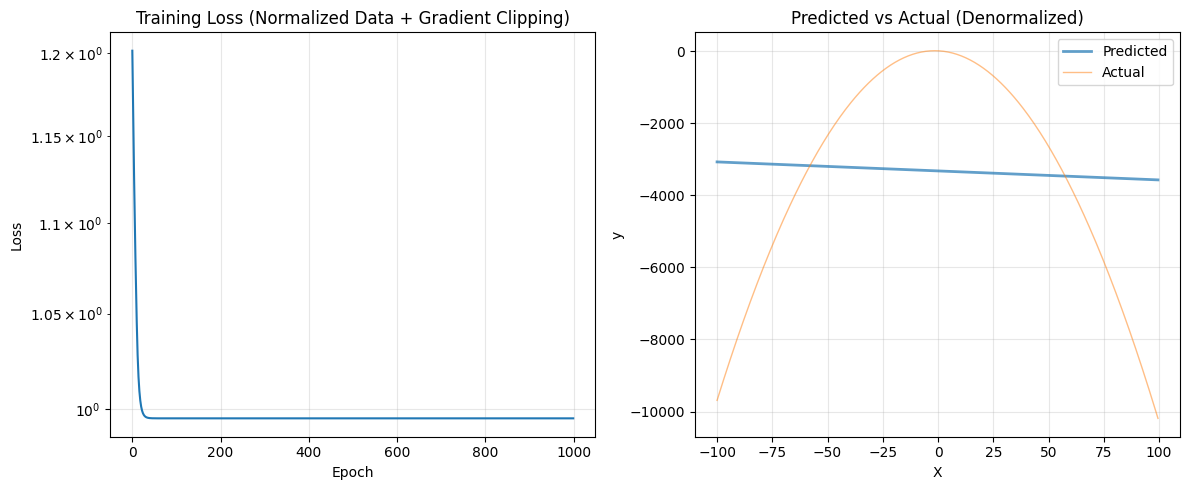

In [166]:
# Linear Model Train with MANUAL gradient clipping (verbose to see what's happening)
print("=" * 60)
print("Linear Model: Training with Normalized X AND Y + MANUAL Gradient Clipping")
print("=" * 60)

linModel = LinearModel()
print("XH shape:", XH.shape)
print(f"Original Data range - X: [{XH.min():.1f}, {XH.max():.1f}], y: [{y.min():.1f}, {y.max():.1f}]")
print()

# Normalize BOTH X and y
XH_mean_lin, XH_std_lin = XH.mean(), XH.std()
y_mean_lin, y_std_lin = y.mean(), y.std()

XH_norm_lin = (XH - XH_mean_lin) / XH_std_lin
y_norm_lin = (y - y_mean_lin) / y_std_lin

print(f"Normalized Data range - X: [{XH_norm_lin.min():.2f}, {XH_norm_lin.max():.2f}], y: [{y_norm_lin.min():.2f}, {y_norm_lin.max():.2f}]")
print()

# Train with verbose=True to see clipping in action
loss = trainModel(linModel, XH_norm_lin, y_norm_lin, n=1000, lr=0.01, clip_grad=True, max_norm=1.0, verbose=True)

# Plot loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(loss)
plt.title("Training Loss (Normalized Data + Gradient Clipping)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale('log')
plt.grid(True, alpha=0.3)

# Predictions on normalized data
y_pred_norm = linModel(XH_norm_lin)

# DENORMALIZE predictions back to original scale
y_pred = y_pred_norm * y_std_lin + y_mean_lin

print(f"\nFinal loss (normalized): {loss[-1]:.4f}")
print(f"y_pred range (denormalized): [{y_pred.min():.2f}, {y_pred.max():.2f}]")
print(f"y_actual range: [{y.min():.2f}, {y.max():.2f}]")
print(f"No NaN values: {not torch.isnan(y_pred).any()}")

# Plot predictions vs actual (both in original scale)
plt.subplot(1, 2, 2)
plt.plot(XH.detach().numpy(), y_pred.detach().numpy(), label="Predicted", alpha=0.7, linewidth=2)
plt.plot(XH.detach().numpy(), y.detach().numpy(), label="Actual", alpha=0.5, linewidth=1)
plt.legend()
plt.title("Predicted vs Actual (Denormalized)")
plt.xlabel("X")
plt.ylabel("y")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [167]:
# Make predictions for linear data
inp = torch.tensor([[50.0], [-25.0], [0.0]])
make_predictions(linModel, inp, XH_mean_lin, XH_std_lin, y_mean_lin, y_std_lin)


Making Predictions on New Data
New X values (original scale): [50.0, -25.0, 0.0]
New X values (normalized): [0.869269609451294, -0.42814770340919495, 0.004324724432080984]

X          Actual y        Linear Pred     Error          
------------------------------------------------------------
50.0       -2639.00        -3447.25        808.25         
-25.0      -539.00         -3259.75        2720.75        
0.0        11.00           -3322.25        3333.25        


* Now let's try with a non linear model

In [168]:
# Les check this with a non linear activation
class NonLinearModel(torch.nn.Module):
    def __init__(self):
        super(NonLinearModel, self).__init__()
        self.linear1 = torch.nn.Linear(1, 15)
        self.linear2 = torch.nn.Linear(15, 1)
        self.relu = torch.nn.GELU()
    
    def forward(self, x):
        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x)
        return x

Non Linear Model: Training with Normalized X AND Y + MANUAL Gradient Clipping
XH shape: torch.Size([400, 1])
Original Data range - X: [-100.0, 99.5], y: [-10187.8, 13.2]

Normalized Data range - X: [-1.73, 1.73], y: [-2.30, 1.12]

Epoch 0: Gradient norm 0.41 <= 1.0, no clipping needed
Epoch 1: Gradient norm 0.38 <= 1.0, no clipping needed
Epoch 2: Gradient norm 0.37 <= 1.0, no clipping needed
Epoch 3: Gradient norm 0.37 <= 1.0, no clipping needed
Epoch 4: Gradient norm 0.38 <= 1.0, no clipping needed

Final loss (normalized): 0.0001
y_pred range (denormalized): [-10086.77, -15.14]
y_actual range: [-10187.75, 13.25]
No NaN values: True


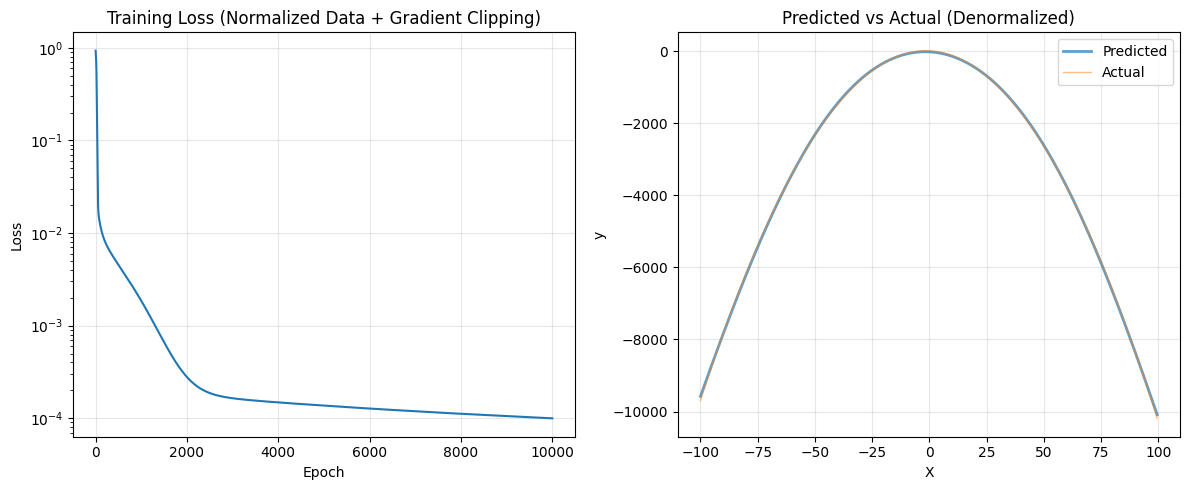

In [169]:
# Train with MANUAL gradient clipping (verbose to see what's happening)
print("=" * 60)
print("Non Linear Model: Training with Normalized X AND Y + MANUAL Gradient Clipping")
print("=" * 60)

nonLinModel = NonLinearModel()
print("XH shape:", XH.shape)
print(f"Original Data range - X: [{XH.min():.1f}, {XH.max():.1f}], y: [{y.min():.1f}, {y.max():.1f}]")
print()

# Normalize BOTH X and y
XH_mean_nl, XH_std_nl = XH.mean(), XH.std()
y_mean_nl, y_std_nl = y.mean(), y.std()

XH_norm_nl = (XH - XH_mean_nl) / XH_std_nl
y_norm_nl = (y - y_mean_nl) / y_std_nl

print(f"Normalized Data range - X: [{XH_norm_nl.min():.2f}, {XH_norm_nl.max():.2f}], y: [{y_norm_nl.min():.2f}, {y_norm_nl.max():.2f}]")
print()

# Train with verbose=True to see clipping in action
loss = trainModel(nonLinModel, XH_norm_nl, y_norm_nl, n=10000, lr=0.1, clip_grad=True, max_norm=1.0, verbose=True)

# Plot loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(loss)
plt.title("Training Loss (Normalized Data + Gradient Clipping)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale('log')
plt.grid(True, alpha=0.3)

# Predictions on normalized data
y_pred_norm = nonLinModel(XH_norm_nl)

# DENORMALIZE predictions back to original scale
y_pred = y_pred_norm * y_std_nl + y_mean_nl

print(f"\nFinal loss (normalized): {loss[-1]:.4f}")
print(f"y_pred range (denormalized): [{y_pred.min():.2f}, {y_pred.max():.2f}]")
print(f"y_actual range: [{y.min():.2f}, {y.max():.2f}]")
print(f"No NaN values: {not torch.isnan(y_pred).any()}")

# Plot predictions vs actual (both in original scale)
plt.subplot(1, 2, 2)
plt.plot(XH.detach().numpy(), y_pred.detach().numpy(), label="Predicted", alpha=0.7, linewidth=2)
plt.plot(XH.detach().numpy(), y.detach().numpy(), label="Actual", alpha=0.5, linewidth=1)
plt.legend()
plt.title("Predicted vs Actual (Denormalized)")
plt.xlabel("X")
plt.ylabel("y")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Make predictions for non liner model
inp = torch.tensor([[67.1], [-2.0], [23]])
make_predictions(nonLinModel, inp, XH_mean_nl, XH_std_nl, y_mean_nl, y_std_nl)




Making Predictions on New Data
New X values (original scale): [67.0999984741211, -2.0, 23.0]
New X values (normalized): [1.1650807857513428, -0.0302730705589056, 0.4021993577480316]

X          Actual y        Linear Pred     Error          
------------------------------------------------------------
67.1       -4692.71        -4708.39        15.68          
-2.0       13.00           -15.14          28.14          
23.0       -587.00         -587.63         0.63           
